---

<table style="width:100%">
  <tr>
    <th>
        <div style="text-align: center; background-color: #f0f0f0; padding: 20px; border-radius: 10px;">
<p style="text-align: center;"> Конспект лекцій з предмету: </p>
<p style="text-align: center;"><b><h2>"Електронні прилади та мікроелектроніка"</h2></b></p>
<p style="text-align: center;"><b><h3>Лекція 8. Польові транзистори з керуючим p-n переходом</h3></b></p>
<p style="text-align: center;"> Національний університет "Чернігівська політехніка"</p>
<p style="text-align: center;"><b>Кафедра:</b> Радіотехніки та відеоінформаційних систем (РТВС)</p>
<hr/>
<p style="text-align: center;"><b>Теми лекції:</b></p>
<ul style="text-align: left;">
  <li>Уніполярні (польові) транзистори: класифікація</li>
  <li>Будова і принцип дії польового транзистора з керуючим p-n переходом (JFET)</li>
  <li>Перекриття каналу, напруга відсічки</li>
  <li>Вихідні та передавальна характеристики, рівняння Шоклі</li>
  <li>Параметри: крутизна, внутрішній опір, коефіцієнт підсилення</li>
  <li>JFET як керований резистор; каскад зі спільним витоком з автозміщенням; термостабільна точка</li>
</ul>
</div>
    </th>
    <th>
<div style="text-align: center; background-color: #f0f0f0; padding: 20px; border-radius: 10px;">
<p style="text-align: center;"> <b>Викладач:</b> </p>
<p style="text-align: center;"> Доктор філософії, Кафедра РТВС</p>
<p style="text-align: center;"> Пахалюк Богдан Петрович</p>
<img src="./Teacher.jpg" alt="" width="110" >
<hr/>
<p style="text-align: center; font-size: 0.9em;">Лекція 8 з 13</p>
</div>
    </th>
  </tr>
</table>

---

---

<p style="text-align: center;"><b>Зміст</b></p>

* [Класифікація польових транзисторів](#fet-classes)
* [Будова і принцип дії JFET](#jfet-principle)
    * [🔬 Розрахунок: форма каналу при різних напругах](#jfet-channel)
* [Статичні характеристики JFET](#jfet-characteristics)
    * [⚙️ PySpice: вихідні та передавальна характеристики BF245B](#spice-jfet)
* [Параметри JFET](#jfet-params)
* [JFET як резистор, керований напругою](#jfet-vcr)
    * [⚙️ PySpice: керований атенюатор](#spice-vcr)
* [Каскад зі спільним витоком з автоматичним зміщенням](#jfet-amp)
    * [⚙️ PySpice: вибір робочої точки і підсилення](#spice-jfet-amp)
* [Температурні властивості. Термостабільна точка](#jfet-temperature)
* [📌 Підсумок лекції](#summary)
* [📚 Рекомендована література](#references)

> 💡 Код демонстрацій та інтерактивних графіків **згорнуто**, щоб не відволікати від матеріалу. Щоб переглянути його, натисніть на «⋯» (або на смужку ліворуч від комірки). Для роботи інтерактивних елементів виконайте всі комірки: *Run → Run All Cells*. Позначка 🔬 — інтерактивне моделювання (повзунки), ⚙️ — моделювання схеми в **PySpice/ngspice**.

---

**Підключення бібліотек.** NumPy/Matplotlib — чисельні розрахунки та графіки, ipywidgets — інтерактивні повзунки, PySpice + ngspice — схемотехнічне моделювання, schemdraw — побудова схем з умовними позначеннями за ДСТУ/IEC. SPICE-моделі реальних приладів зібрано в теці `models/`. Цю комірку потрібно виконати першою.

In [1]:
import warnings
warnings.filterwarnings('ignore', message='Unable to import Axes3D')
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from ipywidgets import interact, interactive, fixed, HBox, VBox, Output
import ipywidgets as widgets
from IPython.display import display, HTML, Markdown
%matplotlib inline

import PySpice.Logging.Logging as Logging
logger = Logging.setup_logging(logging_level='ERROR')
from PySpice.Spice.Netlist import Circuit
from PySpice.Unit import *

# ngspice ≥ 41 пише в stderr інформаційні повідомлення (напр. "Using SPARSE 1.3 as Direct Linear Solver"),
# які PySpice 1.5 вважає помилкою симуляції. Сприймаємо як помилку лише рядки, що містять "error".
from PySpice.Spice.NgSpice import Shared as _ngspice_shared
_orig_send_char = _ngspice_shared.NgSpiceShared._send_char
def _send_char(message_c, ngspice_id, user_data):
    message = _ngspice_shared.ffi_string_utf8(message_c)
    prefix, _, content = message.partition(' ')
    if prefix == 'stderr' and 'error' not in content.lower() and 'init file' not in content:
        self = _ngspice_shared.ffi.from_handle(user_data)
        self._stderr.append(content)
        return self.send_char(message, ngspice_id)
    return _orig_send_char(message_c, ngspice_id, user_data)
_ngspice_shared.NgSpiceShared._send_char = staticmethod(_send_char)

MODELS = 'models'   # тека з SPICE-моделями реальних приладів
def lib(name):
    """Шлях до бібліотеки моделей: lib('diodes') -> models/diodes.lib"""
    return f'{MODELS}/{name}.lib'

try:
    import schemdraw
    import schemdraw.elements as elm
    SCHEMDRAW_AVAILABLE = True
except ImportError:
    SCHEMDRAW_AVAILABLE = False
    print('schemdraw не встановлено (pip install schemdraw)')

plt.rcParams.update({
    'figure.figsize': (8, 4), 'axes.grid': True, 'grid.alpha': 0.3,
    'axes.labelsize': 12, 'axes.titlesize': 13, 'lines.linewidth': 2,
    'font.size': 11,
})

if SCHEMDRAW_AVAILABLE:
    # Умовні позначення за ДСТУ/IEC: резистор — прямокутник, джерело ЕРС — коло зі стрілкою
    from schemdraw.segments import Segment
    from schemdraw.elements.transistors import jfetw, fetl
    elm.style(elm.STYLE_IEC)

    class EMF(elm.Source):
        """Джерело ЕРС: стрілка всередині кола вказує напрямок дії ЕРС."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(.2, 0), (.8, 0)], arrow='->', arrowwidth=.16, arrowlength=.25))

    class CurrentSource(elm.Source):
        """Джерело струму: подвійна стрілка вказує напрямок струму."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(.15, 0), (.85, 0)], arrow='->', arrowwidth=.16, arrowlength=.2))
            self.segments.append(Segment([(.15, 0), (.62, 0)], arrow='->', arrowwidth=.16, arrowlength=.2))

    class JFetNch(elm.JFet):
        """Польовий транзистор з p-n переходом і каналом n-типу: стрілка затвора спрямована ДО каналу."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(jfetw + .3, -fetl - jfetw), (jfetw, -fetl - jfetw)],
                                         arrow='->', arrowwidth=.2, arrowlength=.25))

    class JFetPch(elm.JFet):
        """Польовий транзистор з p-n переходом і каналом p-типу: стрілка затвора спрямована ВІД каналу."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(jfetw + .05, -fetl - jfetw), (jfetw + .35, -fetl - jfetw)],
                                         arrow='->', arrowwidth=.2, arrowlength=.25))

# Фізичні сталі
q = 1.602176634e-19      # Кл, елементарний заряд
k_B = 1.380649e-23       # Дж/К, стала Больцмана
eps0 = 8.8541878128e-12  # Ф/м, електрична стала
def phi_T(T=300.0):
    """Температурний потенціал kT/q, В"""
    return k_B * T / q

# Модель BF245B з типовими температурними коефіцієнтами (VTOTC — дрейф напруги відсічки, BETATCE — рухливості)
JFET_T = dict(VTO=-3.21, BETA=3.05e-3, LAMBDA=8.86e-3, RD=258, RS=184, IS=5.64e-15, PB=1, FC=0.5,
              CGS=3.85e-12, CGD=1.15e-12, VTOTC=-2.5e-3, BETATCE=-0.5)

---

# Класифікація польових транзисторів <a class="anchor" id="fet-classes"></a>

### 🎯 Мета вивчення розділу

<div style="background-color: #eef2ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #4f46e5; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

> Після вивчення цього розділу студент повинен вміти:
> - Класифікувати польові транзистори і читати їх умовні позначення
> - Пояснювати будову й принцип дії JFET, явище перекриття каналу
> - Будувати вихідні та передавальну характеристики і користуватися рівнянням Шоклі
> - Визначати крутизну, внутрішній опір і коефіцієнт підсилення JFET
> - Розраховувати каскад зі спільним витоком з автоматичним зміщенням
> - Пояснювати існування термостабільної точки JFET

</div>


### 📖 Ключові поняття

| Поняття | Визначення |
|---------|-----------|
| **Польовий (уніполярний) транзистор** | Транзистор, струм якого переносять основні носії одного знаку по каналу, а провідністю каналу керує електричне поле |
| **Витік (В, S), стік (С, D), затвор (З, G)** | Електроди, звідки носії входять у канал, куди виходять і якими керують |
| **Напруга відсічки $U_{ЗВ.відс}$** | Напруга затвор–витік, при якій канал повністю перекривається ($I_С$ → 0) |
| **$I_{С.поч}$ ($I_{DSS}$)** | Струм стоку в насиченні при $U_{ЗВ} = 0$ — максимальний струм JFET |
| **Крутизна $S$ ($g_m$)** | $S = \partial I_С/\partial U_{ЗВ}$ при $U_{СВ}$ = const |
| **Внутрішній опір $r_i$** | $r_i = \partial U_{СВ}/\partial I_С$ при $U_{ЗВ}$ = const; $\mu = S\,r_i$ — статичний коефіцієнт підсилення |

**Польовий транзистор** (ПТ, англ. FET — field-effect transistor) — прилад, у якому струм протікає **провідним каналом** між **витоком** і **стоком**, а провідність каналу змінюється **електричним полем**, створеним напругою на **затворі**. На відміну від біполярного, у польовому транзисторі струм переносять лише **основні носії одного знаку** (звідси «уніполярний»), немає інжекції неосновних носіїв і пов'язаних з нею накопичення заряду та теплового розгону. Затвор ізольований від каналу зворотно зміщеним p-n переходом або діелектриком, тому **вхідний опір** дуже великий ($10^9$–$10^{15}$ Ом), а керування — **напругою**, а не струмом.

| Тип | Затвор | Канал при $U_{ЗВ}$ = 0 | Робоча полярність $U_{ЗВ}$ (n-канал) |
|---|---|---|---|
| **З керуючим p-n переходом (JFET)** | p-n перехід | є (збіднення) | від'ємна: 0 … $U_{ЗВ.відс}$ |
| **МДН зі вбудованим каналом** | метал–діелектрик | є | обидві: збіднення і збагачення |
| **МДН з індукованим каналом** | метал–діелектрик | немає | додатна: вище порогу $U_{пор}$ |
| **З бар'єром Шотки (MESFET, HEMT)** | контакт Шотки | є | від'ємна (GaAs, GaN — НВЧ) |

Позначення за ДСТУ — **VT**; стрілка на затворі JFET показує напрямок p-n переходу затвор–канал: для n-каналу вона спрямована **до каналу**, для p-каналу — **від каналу**.

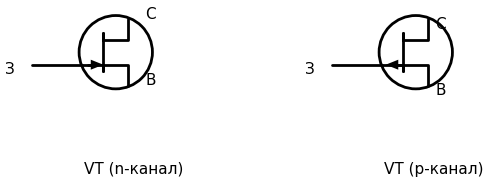

In [2]:
if SCHEMDRAW_AVAILABLE:
    with schemdraw.Drawing(fontsize=11, unit=2) as d:
        for x0, E, name in [(0, JFetNch, 'n-канал'), (6, JFetPch, 'p-канал')]:
            t = d.add(E(circle=True).at((x0, 0)).theta(0).reverse())
            d.add(elm.Label().at((t.drain[0] + 0.35, t.drain[1])).label('С'))
            d.add(elm.Label().at((t.source[0] + 0.35, t.source[1])).label('В'))
            d.add(elm.Line().at(t.gate).left(1.0)); d.add(elm.Label().at((t.gate[0] - 1.35, t.gate[1])).label('З'))
            d.add(elm.Label().at((t.drain[0] + 0.2, t.drain[1] - 2.9)).label(f'VT ({name})'))

---

# Будова і принцип дії JFET <a class="anchor" id="jfet-principle"></a>

N-канальний JFET — це шар n-типу (**канал**) з омічними контактами на кінцях (витік і стік), з обох боків якого сформовано сильно леговані $p^+$-області **затвора** (у планарній конструкції нижній затвор — підкладка, з'єднана з верхнім). Затвор з каналом утворює p-n перехід, який **завжди зміщений у зворотному напрямку** (або має нульове зміщення): $U_{ЗВ} \le 0$ для n-каналу.

1. **Керування затвором.** ОПЗ $p^+$-n переходу поширюється майже повністю в слабше легований канал. Що більша зворотна напруга на затворі, то ширша ОПЗ і тонший провідний переріз каналу. При $U_{ЗВ} = U_{ЗВ.відс}$ ОПЗ верхнього й нижнього затворів змикаються — канал **перекритий**, струм стоку припиняється.
2. **Вплив напруги стоку.** Струм стоку створює спад напруги вздовж каналу: потенціал каналу зростає від 0 біля витоку до $U_{СВ}$ біля стоку. Отже, зворотна напруга на переході біля стоку ($|U_{ЗВ}| + U_{СВ}$) більша, ніж біля витоку, і канал має **клиноподібну** форму — звужується до стоку.
3. **Насичення.** Коли $U_{СВ} = U_{ЗВ} - U_{ЗВ.відс}$, канал перекривається біля стоку («перетискання», pinch-off). Подальше зростання $U_{СВ}$ лише трохи подовжує перекриту ділянку, а весь надлишок напруги падає на ній. Струм стоку майже не зростає — **режим насичення** (пологої ділянки). Носії проходять перекриту ділянку, підхоплені сильним полем, як у колекторному переході БТ.

### 🔬 Розрахунок: форма каналу при різних напругах <a class="anchor" id="jfet-channel"></a>

Розрахунок у наближенні плавного каналу (Шоклі) для кремнієвого JFET з двобічним затвором: $N_d = 10^{16}$ см⁻³, напівтовщина каналу $a$ = 0,5 мкм, $\varphi_к$ = 0,8 В. Внутрішня напруга перекриття $U_{p0} = qN_da^2/2\varepsilon$ = 1,93 В, отже $U_{ЗВ.відс} = \varphi_к - U_{p0}$ ≈ −1,13 В. Товщина ОПЗ у кожній точці каналу $w(x) = \sqrt{2\varepsilon(\varphi_к - U_{ЗВ} + V(x))/qN_d}$, де потенціал каналу $V(x)$ знайдено з умови сталості струму вздовж каналу.

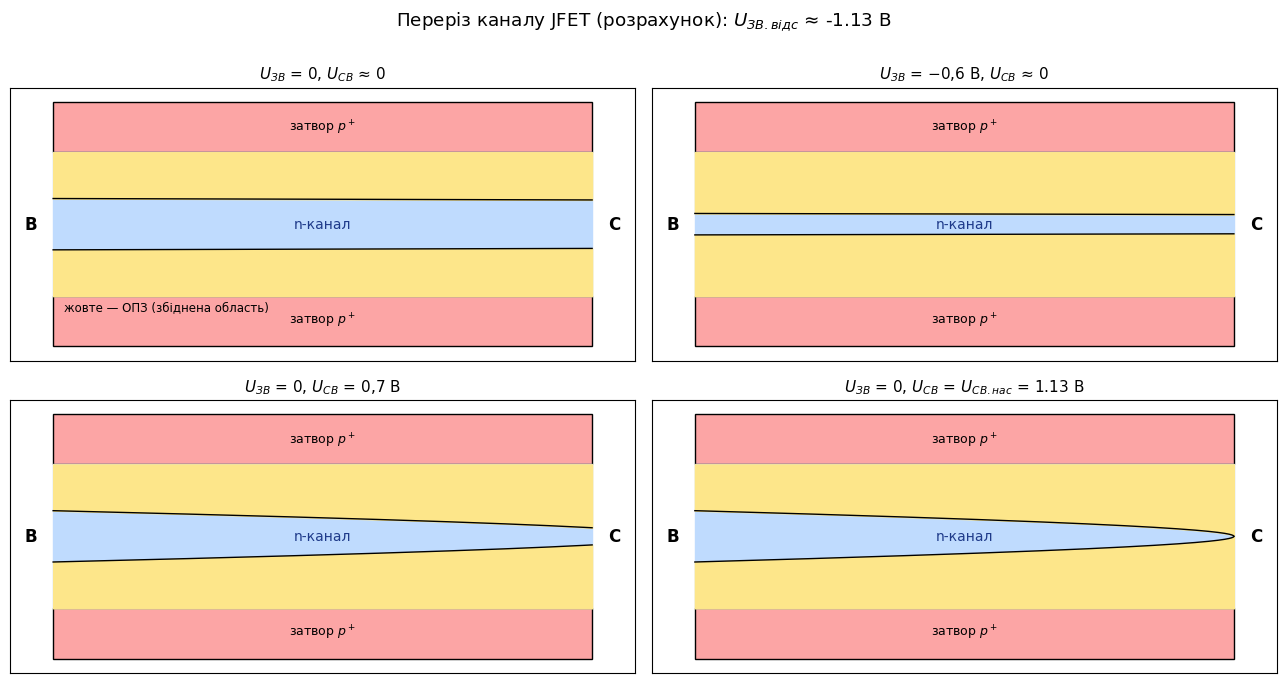

In [3]:
eps = 11.7*eps0*1e-2; Nd = 1e16; a = 0.5e-4; phik = 0.8
Up0 = q*Nd*a**2/(2*eps); U_ots = phik - Up0
def w_of(V, Ugs): return np.minimum(np.sqrt(2*eps*np.clip(phik - Ugs + V, 0, None)/(q*Nd)), a)
def channel(Ugs, Uds, n=400):
    """Потенціал V(x) з рівняння dV/dx ∝ 1/(a - w(V)) (сталий струм уздовж каналу)."""
    Uds_eff = min(Uds, Ugs - U_ots)
    V = np.linspace(0, Uds_eff, n)
    h = a - w_of(V, Ugs)
    F = np.concatenate([[0], np.cumsum(0.5*(h[1:] + h[:-1])*np.diff(V))])
    x = F/F[-1] if F[-1] > 0 else np.linspace(0, 1, n)
    return x, w_of(V, Ugs)
cases = [(0.0, 0.05, '$U_{ЗВ}$ = 0, $U_{СВ}$ ≈ 0'), (-0.6, 0.05, '$U_{ЗВ}$ = −0,6 В, $U_{СВ}$ ≈ 0'),
         (0.0, 0.7, '$U_{ЗВ}$ = 0, $U_{СВ}$ = 0,7 В'), (0.0, -U_ots, f'$U_{{ЗВ}}$ = 0, $U_{{СВ}}$ = $U_{{СВ.нас}}$ = {-U_ots:.2f} В')]
fig, axes = plt.subplots(2, 2, figsize=(13, 6.8))
for ax, (Ugs, Uds, ttl) in zip(axes.flat, cases):
    x, w = channel(Ugs, Uds); a_um = a*1e4; w_um = w*1e4
    ax.add_patch(patches.Rectangle((0, a_um), 1, 0.35, fc='#fca5a5', ec='k')); ax.add_patch(patches.Rectangle((0, -a_um - 0.35), 1, 0.35, fc='#fca5a5', ec='k'))
    ax.fill_between(x, -a_um, a_um, color='#bfdbfe')
    ax.fill_between(x, a_um - w_um, a_um, color='#fde68a'); ax.fill_between(x, -a_um, -a_um + w_um, color='#fde68a')
    ax.plot(x, a_um - w_um, 'k', lw=1); ax.plot(x, -a_um + w_um, 'k', lw=1)
    ax.text(0.5, a_um + 0.17, 'затвор $p^+$', ha='center', va='center', fontsize=9); ax.text(0.5, -a_um - 0.17, 'затвор $p^+$', ha='center', va='center', fontsize=9)
    ax.text(-0.03, 0, 'В', ha='right', va='center', fontsize=12, fontweight='bold'); ax.text(1.03, 0, 'С', va='center', fontsize=12, fontweight='bold')
    ax.text(0.5, 0, 'n-канал', ha='center', va='center', fontsize=10, color='#1e3a8a')
    ax.set_xlim(-0.08, 1.08); ax.set_ylim(-a_um - 0.45, a_um + 0.45); ax.set_title(ttl, fontsize=11); ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
axes[0, 0].text(0.02, -0.6, 'жовте — ОПЗ (збіднена область)', fontsize=8.5)
plt.suptitle(f'Переріз каналу JFET (розрахунок): $U_{{ЗВ.відс}}$ ≈ {U_ots:.2f} В', y=1.0)
plt.tight_layout(); plt.show()

---

# Статичні характеристики JFET <a class="anchor" id="jfet-characteristics"></a>

**Вихідні (стокові) характеристики** $I_С = f(U_{СВ})$ при $U_{ЗВ}$ = const мають області:

- **омічну (крута, тріодна)** — $U_{СВ} < U_{ЗВ} - U_{ЗВ.відс}$: канал ще не перекритий, при малих $U_{СВ}$ транзистор поводиться як резистор, опір якого задає затвор;
- **насичення (пологу)** — $U_{СВ} > U_{ЗВ} - U_{ЗВ.відс}$: струм майже не залежить від $U_{СВ}$ (невеликий нахил — модуляція довжини каналу);
- **пробою** — при великих $U_{СВ}$ пробивається перехід затвор–стік (у SPICE-моделі не відтворюється).

Межа між омічною областю і насиченням — парабола $I_С = I_{С.поч}(U_{СВ}/U_{ЗВ.відс})^2$.

**Передавальна (стоко-затворна) характеристика** в насиченні добре описується **рівнянням Шоклі**:

$$I_С = I_{С.поч}\left(1 - \frac{U_{ЗВ}}{U_{ЗВ.відс}}\right)^2, \qquad U_{ЗВ.відс} \le U_{ЗВ} \le 0.$$

У SPICE-моделі JFET це $I_С = \beta(U_{ЗВ} - V_{TO})^2(1 + \lambda U_{СВ})$, тобто $I_{С.поч} = \beta V_{TO}^2$, $V_{TO} = U_{ЗВ.відс}$. Модель також містить об'ємні опори витоку $R_S$ і стоку $R_D$. Спад напруги на $R_S$ зменшує напругу, прикладену безпосередньо до переходу: $U_{ЗВ.вн} = U_{ЗВ} - I_СR_S$.

### ⚙️ PySpice: вихідні та передавальна характеристики BF245B <a class="anchor" id="spice-jfet"></a>

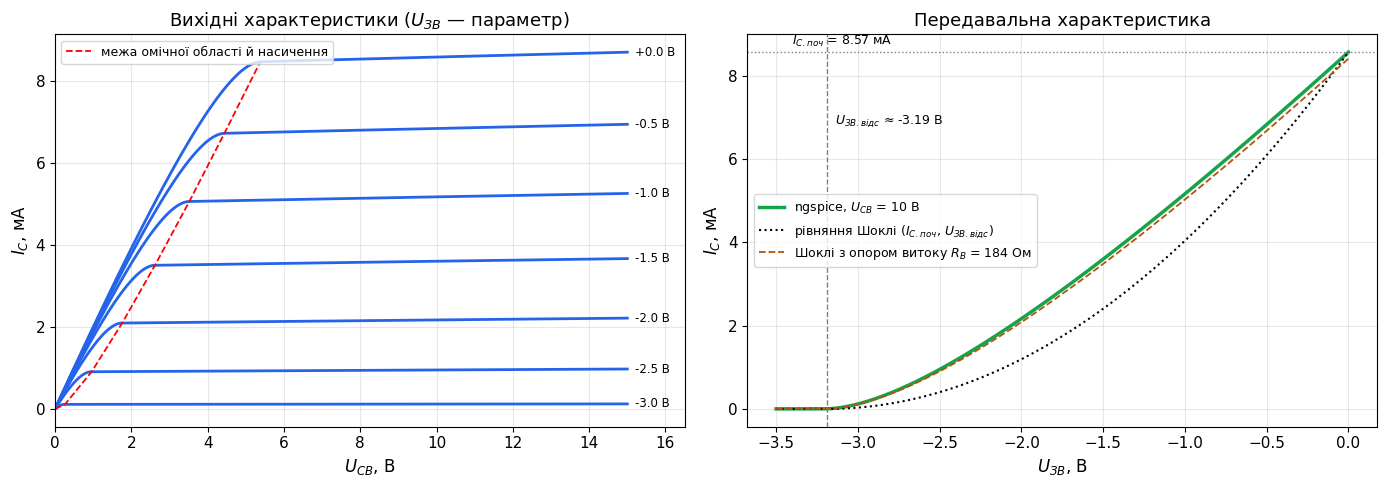

BF245B: I_С.поч = 8.57 мА (паспорт 6–15 мА), U_ЗВ.відс ≈ -3.19 В (паспорт −0,25 … −8 В)
Модель містить об'ємні опори витоку й стоку (RS = 184 Ом, RD = 258 Ом): спад I_С·RS зменшує ефективну напругу затвор–канал,
тому реальна характеристика «лінійніша» за ідеальну параболу Шоклі і збігається з розрахунком, що враховує RS.


In [4]:
c = Circuit('JFET'); c.include(lib('jfet'))
c.V('gs', 'g', c.gnd, 0); c.V('ds', 'd', c.gnd, 0); c.JFET(1, 'd', 'g', c.gnd, model='BF245B')
Ugs_list = np.arange(-3.0, 0.01, 0.5)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
knees = []
for Ugs in Ugs_list:
    c['Vgs'].dc_value = Ugs
    an = c.simulator().dc(Vds=slice(0, 15, 0.02))
    U, I = np.array(an.sweep), -np.array(an.branches['vds'])
    axes[0].plot(U, I*1e3, color='#2563eb')
    axes[0].text(15.2, I[-1]*1e3, f'{Ugs:+.1f} В', va='center', fontsize=8.5)
    g = np.gradient(I, U); k = np.argmax(g < 3*g[-1])                        # «коліно»: нахил упав до ~ нахилу насичення
    knees.append((U[k], I[k]))
# межа насичення за рівнянням Шоклі
c['Vds'].dc_value = 10; an = c.simulator().dc(Vgs=slice(-3.5, 0, 0.005))
Ug, Id = np.array(an.sweep), -np.array(an.branches['vds'])
Idss = Id[-1]; Uots = Ug[np.argmax(Id > 1e-6)]
kn = np.array([(0, 0)] + sorted(knees)); axes[0].plot(kn[:, 0], kn[:, 1]*1e3, 'r--', lw=1.3, label='межа омічної області й насичення')
axes[0].set_xlabel('$U_{СВ}$, В'); axes[0].set_ylabel('$I_С$, мА'); axes[0].set_xlim(0, 16.5); axes[0].legend(fontsize=9, loc='upper left')
axes[0].set_title('Вихідні характеристики ($U_{ЗВ}$ — параметр)')
axes[1].plot(Ug, Id*1e3, color='#16a34a', lw=2.5, label='ngspice, $U_{СВ}$ = 10 В')
axes[1].plot(Ug, Idss*(1 - Ug/Uots)**2*(Ug > Uots)*1e3, 'k:', lw=1.5, label='рівняння Шоклі ($I_{С.поч}$, $U_{ЗВ.відс}$)')
# Шоклі для «внутрішнього» транзистора + опір витоку моделі RS = 184 Ом: I = β(Uзв − I·RS − VTO)^2
from scipy.optimize import brentq
beta_m, Vto_m, RS_m = 3.05e-3, -3.21, 184.0
I_rs = [brentq(lambda I: I - beta_m*max(u - I*RS_m - Vto_m, 0)**2, 0, 0.05) if u > Vto_m else 0 for u in Ug]
axes[1].plot(Ug, np.array(I_rs)*1e3, '--', color='#b45309', lw=1.3, label='Шоклі з опором витоку $R_В$ = 184 Ом')
axes[1].axvline(Uots, color='gray', ls='--', lw=1); axes[1].text(Uots + 0.05, Idss*0.8e3, f'$U_{{ЗВ.відс}}$ ≈ {Uots:.2f} В', fontsize=9)
axes[1].axhline(Idss*1e3, color='gray', ls=':', lw=1); axes[1].text(-3.4, Idss*1e3*1.02, f'$I_{{С.поч}}$ = {Idss*1e3:.2f} мА', fontsize=9)
axes[1].set_xlabel('$U_{ЗВ}$, В'); axes[1].set_ylabel('$I_С$, мА'); axes[1].set_title('Передавальна характеристика'); axes[1].legend(fontsize=9, loc='center left')
plt.tight_layout(); plt.show()
print(f'BF245B: I_С.поч = {Idss*1e3:.2f} мА (паспорт 6–15 мА), U_ЗВ.відс ≈ {Uots:.2f} В (паспорт −0,25 … −8 В)')
print('Модель містить об\'ємні опори витоку й стоку (RS = 184 Ом, RD = 258 Ом): спад I_С·RS зменшує ефективну напругу затвор–канал,')
print('тому реальна характеристика «лінійніша» за ідеальну параболу Шоклі і збігається з розрахунком, що враховує RS.')

---

# Параметри JFET <a class="anchor" id="jfet-params"></a>

**Крутизна** (передавальна провідність) — з рівняння Шоклі:

$$S = \frac{\partial I_С}{\partial U_{ЗВ}} = S_0\left(1 - \frac{U_{ЗВ}}{U_{ЗВ.відс}}\right) = \frac{2\sqrt{I_{С.поч}I_С}}{|U_{ЗВ.відс}|}, \qquad S_0 = \frac{2I_{С.поч}}{|U_{ЗВ.відс}|}.$$

Типові значення — 1–20 мА/В, тобто **в десятки разів менші**, ніж у біполярного транзистора при тому самому струмі ($g_m = I_к/\varphi_T$ ≈ 39 мА/В на 1 мА). Це головний недолік польових транзисторів у підсилювачах.

**Внутрішній (вихідний) опір** в насиченні $r_i = 1/(\lambda I_С)$ — десятки–сотні кОм; **статичний коефіцієнт підсилення** $\mu = S\,r_i$ — сотні.

**Вхідний опір** визначається зворотним струмом переходу затвора ($I_З$ ~ 1 пА–1 нА при 25 °C): $R_{вх} \sim 10^9$–$10^{12}$ Ом. Струм затвора подвоюється кожні ~10 °C.

**Ємності**: $C_{ЗВ}$, $C_{ЗС}$ — бар'єрні ємності переходу затвора (одиниці пФ).

**Шуми.** JFET має найнижчий рівень шумів серед транзисторів при великих опорах джерела сигналу (немає дробового шуму струму бази). Тому JFET ставлять у вхідні каскади мікрофонних, п'єзо- і фотопідсилювачів, дозиметрів, операційних підсилювачів (TL071, OPA1641).

---
### ⚠️ Типова помилка

<div style="background-color: #fef2f2; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #dc2626; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

Не можна подавати на затвор n-канального JFET **пряму** напругу більше ≈ 0,5 В: перехід затвор–канал відкривається, з'являється великий струм затвора, і транзистор втрачає головну перевагу — великий вхідний опір (а при великому струмі перехід можна зруйнувати). Робочий діапазон n-канального JFET — $U_{ЗВ.відс} \le U_{ЗВ} \le 0$. Також не плутайте знак $U_{ЗВ.відс}$ у формулі Шоклі: для n-каналу обидві величини від'ємні, і їх відношення додатне.

</div>

---

# JFET як резистор, керований напругою <a class="anchor" id="jfet-vcr"></a>

При малих $|U_{СВ}|$ (десятки–сотні мілівольт) канал JFET — майже лінійний резистор, опір якого задає напруга затвора:

$$r_{СВ} \approx \frac{1}{S_0\,(1 - U_{ЗВ}/U_{ЗВ.відс})}, \qquad r_{СВ} \to \infty \text{ при } U_{ЗВ} \to U_{ЗВ.відс}.$$

Канал симетричний, тому він проводить змінний струм в обох напрямках. Так будують **електронні атенюатори** й системи АРП (автоматичного регулювання підсилення), аналогові ключі і перемикачі, генератори з автоматичним стабілізуванням амплітуди (міст Віна). Щоб зменшити нелінійність, на затвор подають половину напруги стоку.

### ⚙️ PySpice: керований атенюатор <a class="anchor" id="spice-vcr"></a>

Дільник напруги: резистор 1 кОм і канал JFET BF245B до землі. На вхід подано синусоїду амплітудою 100 мВ; напруга на затворі задає коефіцієнт передачі.

In [5]:
def vcr(Ugs=-1.0):
    c = Circuit('JFET attenuator'); c.include(lib('jfet'))
    c.SinusoidalVoltageSource('in', 'in', c.gnd, amplitude=0.1, frequency=1e3)
    c.R('1', 'in', 'd', 1e3); c.JFET(1, 'd', 'g', c.gnd, model='BF245B'); c.V('g', 'g', c.gnd, Ugs)
    tr = c.simulator().transient(step_time=5e-6, end_time=2e-3)
    t = np.array(tr.time)*1e3; uin, uout = np.array(tr['in']), np.array(tr['d'])
    c2 = Circuit('Rds'); c2.include(lib('jfet')); c2.V('ds', 'd', c2.gnd, 0); c2.V('g', 'g', c2.gnd, 0); c2.JFET(1, 'd', 'g', c2.gnd, model='BF245B')
    Ug = np.linspace(-3.1, 0, 60); r = []
    for u in Ug:
        c2['Vg'].dc_value = u; an = c2.simulator().dc(Vds=slice(-0.02, 0.02, 0.01))
        I = -np.array(an.branches['vds']); r.append(0.04/(I[-1] - I[0]))
    r = np.array(r); r_now = np.interp(Ugs, Ug, r)
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.4))
    axes[0].plot(t, uin*1e3, color='gray', label='$u_{вх}$'); axes[0].plot(t, uout*1e3, color='#7c3aed', lw=2, label='$u_{вих}$')
    axes[0].set_xlabel('t, мс'); axes[0].set_ylabel('мВ'); axes[0].legend(); axes[0].set_title(f'$U_{{ЗВ}}$ = {Ugs:.2f} В')
    axes[1].semilogy(Ug, r, color='#16a34a'); axes[1].plot(Ugs, r_now, 'ro')
    import matplotlib.ticker as mticker
    axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:g}')); axes[1].yaxis.set_minor_formatter(mticker.FuncFormatter(lambda v, _: f'{v:g}'))
    axes[1].set_xlabel('$U_{ЗВ}$, В'); axes[1].set_ylabel('$r_{СВ}$, Ом'); axes[1].set_title('Опір каналу при малих $U_{СВ}$'); axes[1].grid(True, which='both', alpha=0.3)
    plt.tight_layout(); plt.show()
    K = (uout.max() - uout.min())/(uin.max() - uin.min())
    print(f'r_СВ = {r_now:.0f} Ом;  коефіцієнт передачі = {K:.3f} (теорія r/(r + 1 кОм) = {r_now/(r_now + 1e3):.3f})')

interact(vcr, Ugs=widgets.FloatSlider(min=-3.2, max=0, step=0.05, value=-1.0, description='$U_{ЗВ}$, В', continuous_update=False));

interactive(children=(FloatSlider(value=-1.0, continuous_update=False, description='$U_{ЗВ}$, В', max=0.0, min…

---

# Каскад зі спільним витоком з автоматичним зміщенням <a class="anchor" id="jfet-amp"></a>

Для JFET робоча напруга затвора від'ємна, і її зручно отримати **без додаткового джерела**: затвор з'єднують із землею через великий резистор $R_З$ (струму затвора немає, отже $U_З = 0$), а у витік вмикають резистор $R_В$. Струм стоку створює на ньому спад $U_В = I_СR_В$, і

$$U_{ЗВ} = -I_СR_В \quad\text{— пряма автозміщення}.$$

Робоча точка — перетин цієї прямої з передавальною характеристикою. Автозміщення одночасно стабілізує робочу точку (від'ємний зворотний зв'язок за постійним струмом). Резистор $R_В$ шунтують конденсатором $C_В$. У середньочастотній області

$$K_U = -S\,(R_С\,\|\,R_н\,\|\,r_i), \qquad R_{вх} = R_З \;(\text{мегаоми}).$$

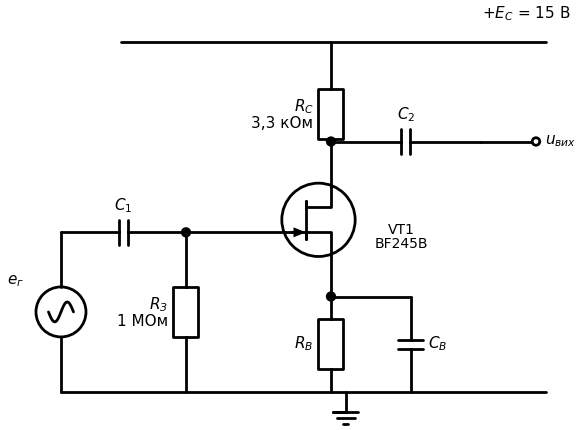

In [6]:
if SCHEMDRAW_AVAILABLE:
    with schemdraw.Drawing(fontsize=11, unit=2.2) as d:
        top, bot = 5.5, -1.5
        t = d.add(JFetNch(circle=True).at((4.2, 2.6)).theta(0).reverse())
        d.add(elm.Line().endpoints((0, top), (8.5, top))); d.add(elm.Label().at((8.0, top + 0.45)).label('$+E_С$ = 15 В'))
        d.add(elm.Line().endpoints((-1.2, bot), (8.5, bot))); d.add(elm.Ground().at((4.5, bot)))
        d.add(elm.SourceSin().endpoints((-1.2, bot), (-1.2, t.gate[1]))); d.add(elm.Label().at((-2.0, 0.6)).label('$e_г$'))
        d.add(elm.Capacitor().endpoints((-1.2, t.gate[1]), (1.3, t.gate[1])).label('$C_1$'))
        d.add(elm.Dot().at((1.3, t.gate[1])))
        d.add(elm.Resistor().endpoints((1.3, t.gate[1]), (1.3, bot)).label('$R_З$\n1 МОм', loc='top'))
        d.add(elm.Line().endpoints((1.3, t.gate[1]), t.gate))
        d.add(elm.Resistor().endpoints((t.drain[0], top), t.drain).label('$R_С$\n3,3 кОм', loc='top'))
        d.add(elm.Line().endpoints(t.source, (t.source[0], 0.4))); d.add(elm.Dot().at((t.source[0], 0.4)))
        d.add(elm.Resistor().endpoints((t.source[0], 0.4), (t.source[0], bot)).label('$R_В$', loc='top'))
        d.add(elm.Line().endpoints((t.source[0], 0.4), (5.8, 0.4))); d.add(elm.Capacitor().endpoints((5.8, 0.4), (5.8, bot)).label('$C_В$', loc='bottom'))
        yd = t.drain[1] + 0.9
        d.add(elm.Dot().at((t.drain[0], yd))); d.add(elm.Capacitor().endpoints((t.drain[0], yd), (7.2, yd)).label('$C_2$'))
        d.add(elm.Line().endpoints((7.2, yd), (8.3, yd))); d.add(elm.Dot(open=True).at((8.3, yd)).label('$u_{вих}$', loc='right'))
        d.add(elm.Label().at((t.drain[0] + 1.3, t.gate[1] - 0.2)).label('VT1\nBF245B', fontsize=10))

### ⚙️ PySpice: вибір робочої точки і підсилення <a class="anchor" id="spice-jfet-amp"></a>

Змінюйте опір автозміщення $R_В$ і стежте, де перетинаються пряма автозміщення та передавальна характеристика BF245B, як змінюються крутизна і підсилення.

In [7]:
c0 = Circuit('tr'); c0.include(lib('jfet')); c0.V('gs', 'g', c0.gnd, 0); c0.V('ds', 'd', c0.gnd, 8); c0.JFET(1, 'd', 'g', c0.gnd, model='BF245B')
an0 = c0.simulator().dc(Vgs=slice(-3.4, 0, 0.005)); Ug_t, Id_t = np.array(an0.sweep), -np.array(an0.branches['vds'])

def jfet_amp(Rs=470):
    c = Circuit('CS self-bias'); c.include(lib('jfet'))
    c.V('dd', 'vdd', c.gnd, 15); c.R('d', 'vdd', 'd', 3.3e3); c.R('s', 's', c.gnd, Rs); c.C('s', 's', c.gnd, 100e-6)
    c.R('g', 'g', c.gnd, 1e6); c.C('1', 'in', 'g', 1e-6)
    c.SinusoidalVoltageSource('in', 'in', c.gnd, amplitude=0.05, frequency=1e3, ac_magnitude=1)
    c.JFET(1, 'd', 'g', 's', model='BF245B')
    op = c.simulator().operating_point()
    Us, Ud = float(op['s'][0]), float(op['d'][0]); Id = Us/Rs; Ugs = -Us
    ac = c.simulator().ac(start_frequency=1e3, stop_frequency=1e4, number_of_points=1, variation='dec')
    Ku = abs(complex(np.array(ac['d'])[0]))
    k = np.argmin(abs(Ug_t - Ugs)); S = np.gradient(Id_t, Ug_t)[k]
    fig, ax = plt.subplots(figsize=(8.5, 4.8))
    ax.plot(Ug_t, Id_t*1e3, color='#16a34a', lw=2.5, label='передавальна характеристика ($U_{СВ}$ = 8 В)')
    ax.plot(Ug_t, -Ug_t/Rs*1e3, 'k--', lw=1.5, label=f'пряма автозміщення $I_С = -U_{{ЗВ}}/R_В$, $R_В$ = {Rs} Ом')
    ax.plot(Ugs, Id*1e3, 'ro', ms=9, label=f'робоча точка: {Ugs:.2f} В, {Id*1e3:.2f} мА')
    ax.set_ylim(0, Id_t.max()*1.1e3); ax.set_xlabel('$U_{ЗВ}$, В'); ax.set_ylabel('$I_С$, мА'); ax.legend(fontsize=9)
    ax.set_title('Графічне визначення робочої точки каскаду з автозміщенням')
    plt.tight_layout(); plt.show()
    print(f'U_ЗВ = {Ugs:.3f} В, I_С = {Id*1e3:.3f} мА, U_СВ = {Ud - Us:.2f} В' + ('  ← УВАГА: вихід з насичення!' if Ud - Us < Ugs - Ug_t[np.argmax(Id_t > 1e-6)] else ''))
    print(f'Крутизна S = {S*1e3:.2f} мА/В;  K_U (ngspice) = {Ku:.2f};  оцінка S·R_С = {S*3.3e3:.2f}')

interact(jfet_amp, Rs=widgets.SelectionSlider(options=[47, 100, 220, 330, 470, 680, 1000, 2200, 4700], value=470,
                                              description='$R_В$, Ом', continuous_update=False));

interactive(children=(SelectionSlider(continuous_update=False, description='$R_В$, Ом', index=4, options=(47, …

---

# Температурні властивості. Термостабільна точка <a class="anchor" id="jfet-temperature"></a>

На струм стоку JFET температура діє двома протилежними шляхами:

- **рухливість** основних носіїв каналу з нагріванням **зменшується** ($\mu \propto T^{-2}$) → струм зменшується; це переважає при великих струмах (біля $I_{С.поч}$);
- **контактна різниця потенціалів** переходу затвора зменшується (≈ −2,2 мВ/К) → ОПЗ звужується, канал розширюється, $|U_{ЗВ.відс}|$ зростає → струм збільшується; це переважає при малих струмах (біля відсічки).

Тому на передавальних характеристиках для різних температур існує **термостабільна точка** — значення $U_{ЗВ}$, при якому струм стоку майже не залежить від температури (для типових JFET — 0,6–0,7 В вище відсічки). Крім того, при великих струмах польовий транзистор **сам себе стабілізує**: нагрівання зменшує струм, тож теплового розгону немає, і польові транзистори можна з'єднувати паралельно без вирівнювальних резисторів.

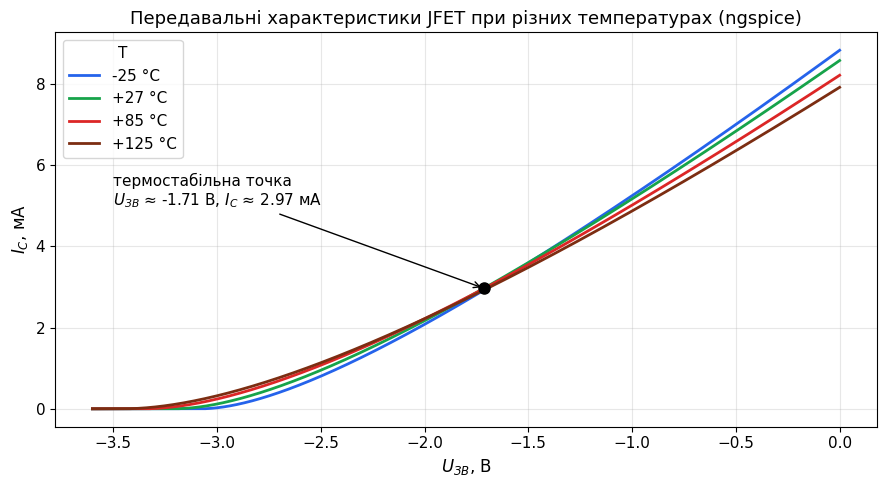

In [8]:
c = Circuit('JFET T'); c.model('JT', 'NJF', **JFET_T)
c.V('ds', 'd', c.gnd, 10); c.V('gs', 'g', c.gnd, 0); c.JFET(1, 'd', 'g', c.gnd, model='JT')
fig, ax = plt.subplots(figsize=(9, 5))
curves = {}
for T, col in [(-25, '#2563eb'), (27, '#16a34a'), (85, '#dc2626'), (125, '#7c2d12')]:
    an = c.simulator(temperature=T, nominal_temperature=27).dc(Vgs=slice(-3.6, 0, 0.002))
    Ug, Id = np.array(an.sweep), -np.array(an.branches['vds']); curves[T] = Id
    ax.plot(Ug, Id*1e3, color=col, lw=2, label=f'{T:+d} °C')
dI = curves[125] - curves[-25]; valid = curves[27] > 0.3e-3                  # шукаємо зміну знаку dI/dT поза околом відсічки
k0 = np.where(valid[:-1] & (np.sign(dI[:-1]) != np.sign(dI[1:])))[0][0]
ax.plot(Ug[k0], curves[27][k0]*1e3, 'ko', ms=8); ax.annotate(f'термостабільна точка\n$U_{{ЗВ}}$ ≈ {Ug[k0]:.2f} В, $I_С$ ≈ {curves[27][k0]*1e3:.2f} мА',
                                                            xy=(Ug[k0], curves[27][k0]*1e3), xytext=(-3.5, 5), arrowprops=dict(arrowstyle='->'))
ax.set_xlabel('$U_{ЗВ}$, В'); ax.set_ylabel('$I_С$, мА'); ax.set_title('Передавальні характеристики JFET при різних температурах (ngspice)')
ax.legend(title='T'); plt.tight_layout(); plt.show()

---
### ✅ Питання для самоперевірки: Польові транзистори з керуючим переходом

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 1.</b> Чому перехід затвор–канал JFET має бути зміщений зворотно?</summary>

> **Відповідь:** Лише тоді затвор не споживає струму і вхідний опір великий; керування здійснюється шириною ОПЗ, яка зростає зі зворотною напругою. При прямому зміщенні з'являється великий струм затвора.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 2.</b> Чому канал JFET звужується біля стоку?</summary>

> **Відповідь:** Потенціал каналу зростає від витоку до стоку через спад напруги від струму стоку, тому зворотна напруга на переході біля стоку ($|U_{ЗВ}| + V(x)$) найбільша, і ОПЗ там найширша.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 3.</b> Чому після перекриття каналу струм стоку майже перестає зростати?</summary>

> **Відповідь:** Надлишок напруги $U_{СВ} - U_{СВ.нас}$ падає на короткій перекритій ділянці біля стоку, а на відкритій частині каналу напруга залишається ≈ $U_{СВ.нас}$ — струм через неї (і через весь канал) майже не змінюється.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 4.</b> Чому JFET можна з'єднувати паралельно, а біполярні транзистори — ні (без вирівнювальних резисторів)?</summary>

> **Відповідь:** При великих струмах $I_С$ JFET зменшується з температурою (падає рухливість), тож гарячіший транзистор бере менше струму. Це саморегуляція. У БТ струм з нагріванням зростає, і гарячіший прилад «перетягує» струм на себе.

</details>

---
### 📝 Задачі для самостійного розв'язання: JFET


<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 1.** JFET: $I_{С.поч}$ = 10 мА, $U_{ЗВ.відс}$ = −4 В. Знайдіть струм стоку і крутизну в насиченні при $U_{ЗВ}$ = −1,5 В.

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $I_С = 10(1 - 1{,}5/4)^2 = 3{,}91$ мА; $S_0 = 2\cdot10/4 = 5$ мА/В; $S = 5(1 - 0{,}375) = 3{,}125$ мА/В.

</details>


<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 2.** Для того самого транзистора знайдіть $R_В$ автозміщення, що дає $I_С$ = 3 мА, і коефіцієнт підсилення каскаду з $R_С$ = 3,3 кОм (витік шунтований, $r_i \gg R_С$).

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $U_{ЗВ} = U_{ЗВ.відс}(1 - \sqrt{I_С/I_{С.поч}}) = -4(1 - \sqrt{0{,}3}) = -1{,}81$ В; $R_В = |U_{ЗВ}|/I_С = 603$ Ом (з ряду — 620 Ом); $S = 2{,}74$ мА/В; $|K_U| = SR_С \approx 9{,}0$.

</details>


<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 3.** Знайдіть опір каналу цього транзистора при малих $U_{СВ}$ для $U_{ЗВ}$ = 0; −2 В; −3 В.

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $r_{СВ} = 1/[S_0(1 - U_{ЗВ}/U_{ЗВ.відс})]$: 200 Ом; 400 Ом; 800 Ом.

</details>


<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 4.** Чим обмежене підсилення каскаду на JFET порівняно з каскадом на БТ при тому самому струмі 1 мА?

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> Крутизною: БТ має $g_m = I/\varphi_T \approx 39$ мА/В, а JFET з $I_{С.поч}$ = 10 мА, $|U_{ЗВ.відс}|$ = 4 В при 1 мА — $S = 2\sqrt{I_{С.поч}I_С}/|U_{ЗВ.відс}| \approx 1{,}6$ мА/В — у 25 разів менше.

</details>

---

## 📌 Підсумок лекції 8: Польові транзистори з керуючим p-n переходом <a class="anchor" id="summary"></a>

<div style="background-color: #f0fdf4; padding: 24px 18px; border-radius: 10px; border-left: 4px solid #16a34a; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

| Величина | Формула | Типові значення |
|---|---|---|
| Рівняння Шоклі | $I_С = I_{С.поч}(1 - U_{ЗВ}/U_{ЗВ.відс})^2$ | $I_{С.поч}$ = 1–20 мА |
| Напруга насичення | $U_{СВ.нас} = U_{ЗВ} - U_{ЗВ.відс}$ | 0,5–5 В |
| Крутизна | $S = 2\sqrt{I_{С.поч}I_С}/|U_{ЗВ.відс}|$ | 1–20 мА/В |
| Опір каналу (омічна обл.) | $r_{СВ} = 1/[S_0(1 - U_{ЗВ}/U_{ЗВ.відс})]$ | 50 Ом – ∞ |
| Вхідний опір | $R_{вх} = U_{ЗВ}/I_З$ | $10^9$–$10^{12}$ Ом |
| Підсилення каскаду СВ | $K_U = -S(R_С\|R_н\|r_i)$ | 5–30 |

**Головні висновки.** (1) JFET керується напругою, яка змінює ширину ОПЗ зворотно зміщеного переходу і переріз каналу. (2) Перекриття каналу біля стоку приводить до насичення струму, а передавальну характеристику описує квадратична залежність Шоклі. (3) Крутизна JFET значно менша, ніж у БТ, зате вхідний опір і шумові властивості — найкращі. (4) Автозміщення дає робочу точку без окремого джерела, а термостабільна точка і від'ємний ТКС великих струмів роблять JFET термостійким.

</div>

---

## 📚 Рекомендована література та ресурси <a class="anchor" id="references"></a>

**Основна література**

1. Прищепа М. М., Погребняк В. П. Мікроелектроніка. Ч. 1. Елементи мікроелектроніки: навч. посібник. — К.: Вища школа, 2004.
2. Бойко В. І., Гуржій А. М., Жуйков В. Я. та ін. Схемотехніка електронних систем. Кн. 1. Аналогова схемотехніка та імпульсні пристрої. — К.: Вища школа, 2004.
3. Sze S. M., Ng K. K. Physics of Semiconductor Devices. — 3rd ed. — Wiley, 2007.
4. Neamen D. A. Semiconductor Physics and Devices: Basic Principles. — 4th ed. — McGraw-Hill, 2012.

**Додаткова література**

5. Sedra A. S., Smith K. C. Microelectronic Circuits. — 8th ed. — Oxford University Press, 2020.
6. Streetman B. G., Banerjee S. K. Solid State Electronic Devices. — 7th ed. — Pearson, 2016.

**Програмні інструменти, що використовуються в конспекті**

- [PySpice](https://pyspice.fabrice-salvaire.fr/) + [ngspice](https://ngspice.sourceforge.io/) — схемотехнічне моделювання (SPICE-моделі приладів — у теці `models/`)
- [SchemDraw](https://schemdraw.readthedocs.io/) — побудова електричних схем
- [NumPy](https://numpy.org/doc/) / [SciPy](https://docs.scipy.org/doc/scipy/) / [Matplotlib](https://matplotlib.org/) — чисельні розрахунки та графіки
- [ipywidgets](https://ipywidgets.readthedocs.io/) — інтерактивні елементи керування

---

<p style="text-align: center;">⬅️ [Лекція 7. Біполярний транзистор у підсилювальному та ключовому режимах](Лекція_07_Біполярний_транзистор_у_динамічному_режимі.ipynb) &nbsp;|&nbsp; [Лекція 9. МДН-транзистори (MOSFET)](Лекція_09_МДН-транзистори.ipynb) ➡️</p>

*Конспект підготовлено: Пахалюк Богдан Петрович, НУ "Чернігівська політехніка"*